# Jigsaw | A complete rule-conditioned NLP project

**Alvaro Mendizabal · Research, modeling, and reproducible ML engineering**

The completed system ranks whether a comment violates a supplied community policy. The retained support-adapted Qwen3-4B model scored **0.91425 private / 0.91808 public Kaggle ROC AUC**, improving private AUC by **0.29469** over the lexical reference.

This review explains the result, the controlled evidence behind adaptation, the feature-transfer lesson, and the final decision. It reads only committed aggregates. It does not fit models, load weights, read raw comments, access private accounts, or submit anything.

In [1]:
from pathlib import Path
import hashlib
import html
import json
import plotly.graph_objects as go
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / "reports/portfolio/closeout.json").is_file():
    if ROOT.parent == ROOT:
        raise RuntimeError("Run this notebook within the project checkout")
    ROOT = ROOT.parent
closeout = json.loads((ROOT / "reports/portfolio/closeout.json").read_text())
for relative, expected in closeout["sources_sha256"].items():
    actual = hashlib.sha256((ROOT / relative).read_bytes()).hexdigest()
    if actual != expected:
        raise ValueError(f"Reviewed evidence changed: {relative}")

def read(relative):
    return json.loads((ROOT / relative).read_text())

receipt = read("reports/checkpoints/kaggle_adaptation.json")
results = read("reports/support_adaptation/results.json")
uncertainty = read("reports/support_adaptation/uncertainty.json")
expanded = read("reports/expanded/results.json")
majority = read("reports/majority_submission/summary.json")
final = closeout["final_model"]
print("Project status:", closeout["status"])
print("Verified public evidence files:", len(closeout["sources_sha256"]))
print("Model: support-adapted Qwen3-4B | late Kaggle evaluation")
print(f"Public AUC {final['public_auc']:.5f} | Private AUC {final['private_auc']:.5f}")
print("No training, private-data access, or cloud actions in this notebook.")

Project status: complete\nVerified public evidence files: 9\nModel: support-adapted Qwen3-4B | late Kaggle evaluation\nPublic AUC 0.91808 | Private AUC 0.91425\nNo training, private-data access, or cloud actions in this notebook.\n

## 1 | How good is the result?

The final model delivers strong ranking performance and a substantial end-to-end improvement. The difference from the documented historical winner is **0.01505 AUC units**, or **1.505 percentage points** on the AUC scale. That is a concrete comparison, not an inferred rank or percentile.

AUC is not accuracy: the result does not mean 91.425% of comments were classified correctly. Both project entries are late evaluations, so neither an original competition placement nor a medal is claimed. The historical winner is an external benchmark, not a reproduced model.

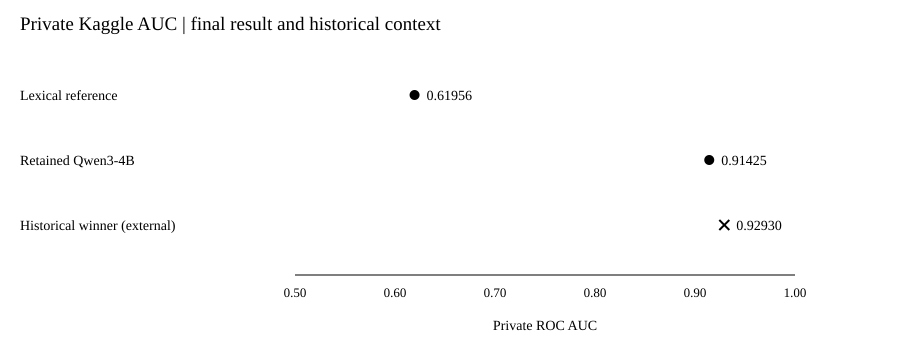

Private improvement: +0.29469 AUC
Gap to historical winning score: 0.01505 AUC


In [2]:
def evidence_plot(labels, values, title, x_label, limits, external=()):
    """Render matching Plotly and SVG dot plots on the same explicit scale."""
    height = 150 + 65 * len(labels)
    symbols = ["x" if i in external else "circle" for i in range(len(labels))]
    fig = go.Figure(go.Scatter(
        x=values, y=labels, mode="markers+text", text=[f"{v:.5f}" for v in values],
        textposition="middle right", marker=dict(size=11, symbol=symbols),
        hovertemplate="%{y}<br>AUC: %{x:.5f}<extra></extra>"))
    fig.update_layout(template="none", title=title, height=height,
        margin=dict(l=265, r=90, t=75, b=65), showlegend=False,
        xaxis=dict(title=x_label, range=limits, tickformat=".2f"),
        yaxis=dict(autorange="reversed", automargin=True))
    left, right, top, bottom = 295, 795, 95, height - 70
    xmin, xmax = limits
    def position(value):
        return left + (right - left) * (value - xmin) / (xmax - xmin)
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 900 {height}" role="img">',
        f'<title>{html.escape(title)}</title>',
        f'<text x="20" y="30" font-size="19">{html.escape(title)}</text>',
        f'<line x1="{left}" y1="{bottom}" x2="{right}" y2="{bottom}" stroke="currentColor"/>']
    for i in range(6):
        value = xmin + (xmax - xmin) * i / 5
        x = position(value)
        parts.append(f'<text x="{x:.2f}" y="{bottom + 22}" text-anchor="middle" font-size="13">{value:.2f}</text>')
    for i, (label, value) in enumerate(zip(labels, values)):
        y = top + 65 * i
        x = position(value)
        parts.append(f'<text x="20" y="{y + 5}" font-size="14">{html.escape(label)}</text>')
        if i in external:
            parts.append(f'<path d="M{x-5:.2f},{y-5} L{x+5:.2f},{y+5} M{x-5:.2f},{y+5} L{x+5:.2f},{y-5}" stroke="currentColor" stroke-width="2"/>')
        else:
            parts.append(f'<circle cx="{x:.2f}" cy="{y}" r="5"/>')
        parts.append(f'<text x="{x + 12:.2f}" y="{y + 5}" font-size="14">{value:.5f}</text>')
    parts.append(f'<text x="{(left+right)/2}" y="{height-15}" text-anchor="middle" font-size="14">{html.escape(x_label)}</text></svg>')
    figure = json.loads(fig.to_json())
    display({"application/vnd.plotly.v1+json": figure, "image/svg+xml": "".join(parts)}, raw=True)
    return figure

score_plot = evidence_plot(
    ["Lexical reference", "Retained Qwen3-4B", "Historical winner (external)"],
    [final["baseline_private_auc"], final["private_auc"], final["historical_winner_private_auc"]],
    "Private Kaggle AUC | final result and historical context", "Private ROC AUC", [0.50, 1.00], external=(2,))
assert abs(final["private_auc"] - final["baseline_private_auc"] - final["private_auc_gain"]) < 1e-12
assert abs(final["historical_winner_private_auc"] - final["private_auc"] - final["gap_to_historical_winner"]) < 1e-12
print(f"Private improvement: +{final['private_auc_gain']:.5f} AUC")
print(f"Gap to historical winning score: {final['gap_to_historical_winner']:.5f} AUC")

## 2 | Why adaptation mattered

**System:** original training labels and supplied labeled examples → audited support pairs → pinned Qwen3-4B + LoRA → decision-position scoring → within-policy ranks → validated output.

A matched development study holds the 4B backbone fixed and evaluates 881 novel comments. Query bodies are removed from all adaptation sources across rules. The study isolates support adaptation rather than attributing every gain in the end-to-end leaderboard comparison to a single change.

The recorded interval is conditional on fixed predictions and the observed policies. The small, repeatedly inspected development cohort is not an untouched final holdout.

In [3]:
by_model = {row["model"]: row for row in results}
frozen = by_model["frozen_raw"]["metrics"]["rule_macro_auc"]
adapted = by_model["adapted_raw"]["metrics"]["rule_macro_auc"]
contrast = next(row for row in uncertainty if row["contrast"] == "support adaptation at fixed backbone")
print(f"Same-backbone development AUC: {frozen:.6f} -> {adapted:.6f}")
print(f"Gain: +{adapted-frozen:.6f}")
print(f"Simultaneous 95% gain interval: [{contrast['simultaneous_lower']:.6f}, {contrast['simultaneous_upper']:.6f}]")
assert abs(adapted-frozen-contrast["observed_delta"]) < 1e-12
print("PLOTLY_SENTINEL_COMPLETE")

Same-backbone development AUC: 0.614600 -> 0.719893
Gain: +0.105293
Simultaneous 95% gain interval: [0.061237, 0.149350]
PLOTLY_SENTINEL_COMPLETE


## 3 | Feature engineering demonstrated judgment, not just volume

The separate four-policy research campaign evaluated lexical, semantic, retrieval, and contextual representations in 323 fixed fits. The full feature model looked strong on familiar policies but deteriorated on held-out policies. The frozen semantic centroid transferred better under that held-out-policy protocol.

This research justified retaining simpler transferable signals rather than promoting a larger bank on familiar-policy fit alone. Its data boundary includes post-competition research data and differs from the neural competition study. The following scores are **not** Kaggle scores.

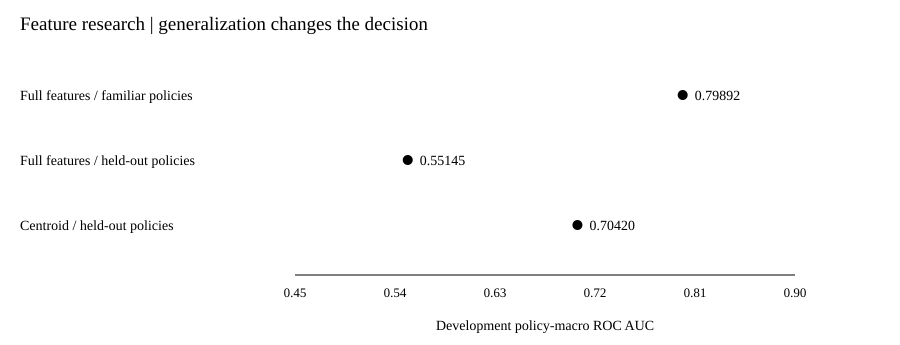

Different validation protocols are labeled explicitly; do not pool these scores.


In [4]:
def metric(model, protocol):
    return next(row["metrics"]["rule_macro_auc"] for row in expanded
                if row["model"] == model and row["protocol"] == protocol)
values = [metric("all_transfer", "seen_rule"), metric("all_transfer", "heldout_rule"), metric("qwen_centroid", "heldout_rule")]
transfer_plot = evidence_plot(
    ["Full features / familiar policies", "Full features / held-out policies", "Centroid / held-out policies"],
    values, "Feature research | generalization changes the decision", "Development policy-macro ROC AUC", [0.45, 0.90])
print("Different validation protocols are labeled explicitly; do not pool these scores.")

## 4 | Reproducibility and the scored supplementary experiment\n\nThe retained neural path preserves exact model/configuration identities, validates schemas and row order, checkpoints optimizer and random state, and reuses completed work under matching contracts. The public repository provides tests, executed analysis, negative results, and recovery documentation. AWS retains private artifacts rather than being mirrored into Git.\n\nThe strict-majority arm is preserved as a scored one-factor experiment. It completed at **0.91720 public / 0.91288 private AUC**, below the retained 4B system, and is therefore rejected. This resolves the earlier pending snapshot without rewriting the historical experiment design.

In [5]:
audit = majority["supervision_audit"]
candidate = closeout["supplementary_candidate"]
print(f"Strict-majority audit: {audit['baseline_retained_pairs']} -> {audit['candidate_retained_pairs']} retained pairs")
print(f"Recovered conflicts: {audit['resolved_majority_pairs']} | Dropped ties: {audit['discarded_tie_pairs']}")
assert audit["uncontested_label_parity"]
assert all(row["purge_passed"] for row in audit["folds"])
print(f"Submission {candidate['submission_ref']}: {candidate['last_verified_status']} at {candidate['last_verified_utc']}")
print(f"Public AUC {candidate['public_auc']:.5f} | Private AUC {candidate['private_auc']:.5f}")
assert candidate["public_auc"] == majority["candidate"]["public_auc"]
assert candidate["private_auc"] == majority["candidate"]["private_auc"]
assert candidate["private_auc"] < final["private_auc"]
assert candidate["promoted"] is False
print("Scored majority candidate rejected; retained system unchanged.")
print("LATEST_CHECKPOINT_COMPLETE")

Strict-majority audit: 1862 -> 1872 retained pairs\nRecovered conflicts: 10 | Dropped ties: 1\nSubmission 56444879: complete at 2026-09-22T22:47:35.410321+00:00\nPublic AUC 0.91720 | Private AUC 0.91288\nScored majority candidate rejected; retained system unchanged.\nLATEST_CHECKPOINT_COMPLETE\n

## Final decision | retain the scored system, continue frontier research\n\n**The historical portfolio release remains complete and the retained scored system remains support-adapted Qwen3-4B at 0.91425 private Kaggle AUC.** Subsequent frontier research does not rewrite that result: strict-majority conflict handling regressed, while Qwen3-14B added useful blend diversity despite weaker standalone development AUC.\n\nThe active next milestone is leakage-safe multi-model OOF ensemble selection across preserved 4B, 8B, 14B, and Phi predictions. Another official submission is reserved for a fixed candidate after AWS validation. No production deployment or autonomous moderation claim is made.\n\n**Evidence:** [scored receipt](../reports/checkpoints/kaggle_adaptation.json), [adaptation results](../reports/support_adaptation/results.json), [uncertainty](../reports/support_adaptation/uncertainty.json), [majority checkpoint](../reports/majority_submission/summary.json), [14B frontier](../docs/QWEN14B_FRONTIER.md), [latest frontier notebook](28_qwen14b_frontier_review.ipynb), [model card](../MODEL_CARD.md).